<a href="https://colab.research.google.com/github/volodymyr-holovan/shopSphere_project/blob/main/Shopsphere_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ShopSphere — Data Analytics & A/B Test Notebook

This version does not use SQL or SQLite. All data preparation, aggregation and joins are done directly in pandas.

Contents:
1. Load data directly from GitHub (raw CSV links)
2. Data validation
3. Pandas equivalents of the five Block 1 queries
4. Supporting analysis for Business Cases A, B, C (Block 4)
5. Statistical analysis of the checkout A/B test, including Simpson's paradox (Block 5)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})

NAVY = '#1f3b57'
TEAL = '#2a9d8f'
ORANGE = '#e76f51'
GREY = '#adb5bd'

In [7]:
customers = pd.read_csv('https://raw.githubusercontent.com/volodymyr-holovan/shopSphere_project/refs/heads/main/data/shopsphere_customers.csv')
products = pd.read_csv('https://raw.githubusercontent.com/volodymyr-holovan/shopSphere_project/refs/heads/main/data/shopsphere_products.csv')
orders = pd.read_csv('https://raw.githubusercontent.com/volodymyr-holovan/shopSphere_project/refs/heads/main/data/shopsphere_orders.csv')
order_items = pd.read_csv('https://raw.githubusercontent.com/volodymyr-holovan/shopSphere_project/refs/heads/main/data/shopsphere_order_items.csv')
marketing = pd.read_csv('https://raw.githubusercontent.com/volodymyr-holovan/shopSphere_project/refs/heads/main/data/shopsphere_marketing.csv')

for name, df in [('customers', customers), ('products', products), ('orders', orders),
                  ('order_items', order_items), ('marketing', marketing)]:
    print(f'{name}: {df.shape[0]} rows, {df.shape[1]} columns')

customers: 3000 rows, 7 columns
products: 250 rows, 6 columns
orders: 12274 rows, 14 columns
order_items: 26068 rows, 7 columns
marketing: 216 rows, 9 columns


In [8]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
customers['signup_date'] = pd.to_datetime(customers['signup_date'])

## Data validation

Referential integrity check: every order must have a matching customer, every order_item must have a matching order and product.

In [9]:
orphan_orders = orders.loc[~orders['customer_id'].isin(customers['customer_id'])]
orphan_items_order = order_items.loc[~order_items['order_id'].isin(orders['order_id'])]
orphan_items_product = order_items.loc[~order_items['product_id'].isin(products['product_id'])]

print('orders without matching customer:', len(orphan_orders))
print('order_items without matching order:', len(orphan_items_order))
print('order_items without matching product:', len(orphan_items_product))

orders without matching customer: 0
order_items without matching order: 0
order_items without matching product: 0


## Block 1 — pandas equivalents of the five SQL queries

Same five results as the SQL version, reproduced with merges and groupby instead of JOIN and GROUP BY.

### 1.1 — revenue_orders_aov_by_region_year

In [10]:
orders_c = orders.merge(customers[['customer_id', 'region']], on='customer_id', how='left')

q1_region_year = (
    orders_c
    .groupby(['region', 'order_year'])
    .agg(order_count=('order_id', 'count'), total_net_revenue=('net_amount', 'sum'), avg_order_value=('net_amount', 'mean'))
    .round(2)
    .reset_index()
    .sort_values(['order_year', 'total_net_revenue'], ascending=[True, False])
)
q1_region_year

,region,order_year,order_count,total_net_revenue,avg_order_value
0,Europe,2022,380,"100,827.26",265.33
9,North America,2022,254,"80,204.08",315.76
12,Southeast Asia,2022,44,"12,721.48",289.12
3,Latin America,2022,54,"12,138.04",224.78
6,Middle East,2022,33,"5,889.80",178.48
1,Europe,2023,1101,"315,070.82",286.17
10,North America,2023,848,"235,736.97",277.99
13,Southeast Asia,2023,335,"106,973.34",319.32
4,Latin America,2023,268,"70,178.83",261.86
7,Middle East,2023,223,"53,547.54",240.12


### 1.2 — top10_customers_by_spend

In [11]:
cust_agg = (
    orders.groupby('customer_id')
    .agg(order_count=('order_id', 'count'), total_spend=('net_amount', 'sum'))
    .round(2)
    .reset_index()
)
q2_top10 = (
    cust_agg.merge(customers[['customer_id', 'region', 'acquisition_channel']], on='customer_id', how='left')
    .sort_values('total_spend', ascending=False)
    .head(10)
    [['customer_id', 'region', 'acquisition_channel', 'order_count', 'total_spend']]
)
q2_top10

,customer_id,region,acquisition_channel,order_count,total_spend
2347,12348,Europe,Influencer,43,"30,360.93"
1130,11131,Europe,Influencer,41,"22,546.65"
2722,12723,North America,Referral,43,"19,561.76"
994,10995,Europe,Influencer,32,"19,496.63"
1386,11387,Southeast Asia,Influencer,35,"18,730.10"
1834,11835,Southeast Asia,Referral,31,"18,114.42"
1045,11046,Europe,Organic,37,"17,960.45"
836,10837,North America,Influencer,27,"17,822.03"
2964,12965,Europe,Email,32,"16,732.93"
2477,12478,North America,Referral,32,"16,412.50"


### 1.3 — category_revenue_margin_returns

In [12]:
items_p = order_items.merge(products[['product_id', 'margin_pct']], on='product_id', how='left')
items_p = items_p.merge(orders[['order_id', 'is_returned']], on='order_id', how='left')

revenue_margin = items_p.groupby('category').agg(total_revenue=('line_total', 'sum'), avg_margin_pct=('margin_pct', 'mean'))

# Return rate must count each distinct order once per category (not once per item row) -
# matches the SQL version's COUNT(DISTINCT o.order_id)
returns = (
    items_p.drop_duplicates(subset=['category', 'order_id'])
    .groupby('category')
    .agg(distinct_orders=('order_id', 'count'), returned_orders=('is_returned', 'sum'))
)
returns['return_rate_pct'] = 100 * returns['returned_orders'] / returns['distinct_orders']

q3_category = (
    revenue_margin.join(returns['return_rate_pct'])
    .round(2)
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)
q3_category

,category,total_revenue,avg_margin_pct,return_rate_pct
3,Electronics,"2,097,901.06",12.00,15.97
4,Home & Kitchen,"576,134.75",35.00,10.27
5,Sports,"343,114.98",30.00,8.40
2,Clothing,"248,601.48",45.00,16.00
0,Beauty,"168,624.42",55.00,9.97
6,Toys,"140,505.55",40.00,8.98
1,Books,"90,757.82",25.00,8.13


### 1.4 — above_average_spenders

In [13]:
avg_spend = cust_agg['total_spend'].mean()
above_avg = cust_agg.loc[cust_agg['total_spend'] > avg_spend]

q4_above_avg = pd.DataFrame([{
    'above_avg_customer_count': len(above_avg),
    'above_avg_total_revenue': round(above_avg['total_spend'].sum(), 2),
    'pct_of_total_revenue': round(100 * above_avg['total_spend'].sum() / cust_agg['total_spend'].sum(), 2),
}])
q4_above_avg

,above_avg_customer_count,above_avg_total_revenue,pct_of_total_revenue
0,862,"2,524,753.93",72.68


### 1.5 — channel_budget_revenue_roi

In [14]:
q5_channel_roi = (
    marketing.groupby('channel')
    .agg(total_budget=('budget', 'sum'), total_attributed_revenue=('attributed_revenue', 'sum'))
    .reset_index()
)
q5_channel_roi['roi'] = (q5_channel_roi['total_attributed_revenue'] / q5_channel_roi['total_budget']).round(2)
q5_channel_roi = q5_channel_roi.round(2).sort_values('roi', ascending=False)
q5_channel_roi

,channel,total_budget,total_attributed_revenue,roi
2,Organic,20364,163398,8.02
0,Email,37468,243610,6.50
1,Influencer,112337,519453,4.62
4,Referral,73766,263536,3.57
5,Social Ads,286488,589544,2.06
3,Paid Search,450959,598703,1.33


---
## Case A — Marketing budget allocation

Campaign ROI only tells half the story. Customer lifetime value (LTV) by acquisition channel shows whether the budget is going to the channels that bring in the most valuable customers, not just the most efficient single campaign.

In [15]:
budget_share = marketing.groupby('channel')['budget'].sum().reset_index()
budget_share['share_pct'] = (100 * budget_share['budget'] / budget_share['budget'].sum()).round(1)
budget_share = budget_share.sort_values('budget', ascending=False)
budget_share

,channel,budget,share_pct
3,Paid Search,450959,46.00
5,Social Ads,286488,29.20
1,Influencer,112337,11.40
4,Referral,73766,7.50
0,Email,37468,3.80
2,Organic,20364,2.10


In [16]:
ltv_by_channel = (
    cust_agg.merge(customers[['customer_id', 'acquisition_channel']], on='customer_id', how='left')
    .groupby('acquisition_channel')
    .agg(customers=('customer_id', 'count'), avg_ltv=('total_spend', 'mean'), total_revenue=('total_spend', 'sum'))
    .round(2)
    .reset_index()
    .sort_values('avg_ltv', ascending=False)
)
ltv_by_channel

,acquisition_channel,customers,avg_ltv,total_revenue
1,Influencer,357,"1,985.73","708,904.17"
4,Referral,266,"1,791.82","476,624.14"
2,Organic,721,"1,316.13","948,926.22"
0,Email,372,"1,074.46","399,698.95"
5,Social Ads,619,822.09,"508,872.82"
3,Paid Search,665,648.10,"430,989.73"


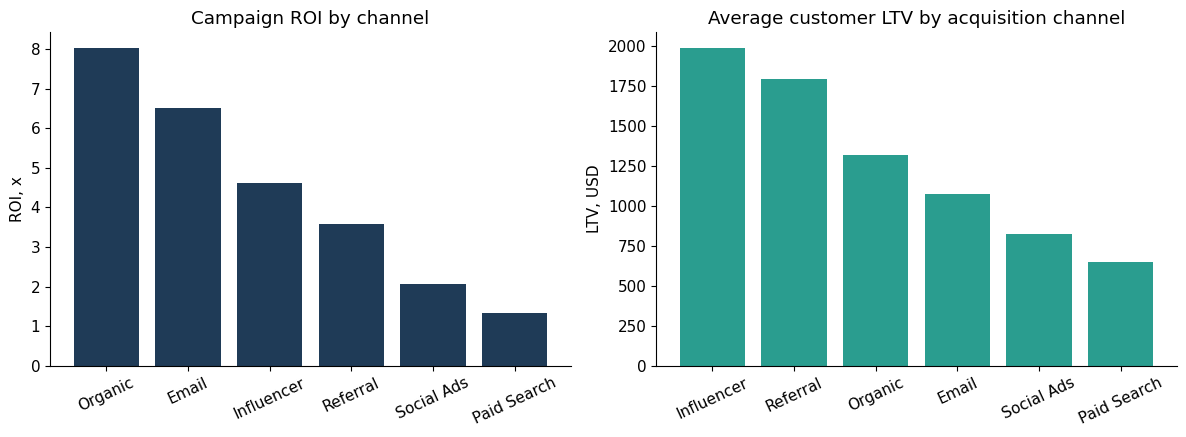

Does the channel with the best campaign ROI also have the best LTV?
       channel  roi  avg_ltv
0      Organic 8.02 1,316.13
1        Email 6.50 1,074.46
2   Influencer 4.62 1,985.73
3     Referral 3.57 1,791.82
4   Social Ads 2.06   822.09
5  Paid Search 1.33   648.10


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

d = q5_channel_roi.sort_values('roi', ascending=False)
ax1.bar(d['channel'], d['roi'], color=NAVY)
ax1.set_title('Campaign ROI by channel')
ax1.set_ylabel('ROI, x')
ax1.tick_params(axis='x', rotation=25)

l = ltv_by_channel.sort_values('avg_ltv', ascending=False)
ax2.bar(l['acquisition_channel'], l['avg_ltv'], color=TEAL)
ax2.set_title('Average customer LTV by acquisition channel')
ax2.set_ylabel('LTV, USD')
ax2.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

print('Does the channel with the best campaign ROI also have the best LTV?')
merged = d.merge(l, left_on='channel', right_on='acquisition_channel')
print(merged[['channel', 'roi', 'avg_ltv']].sort_values('roi', ascending=False))

**Finding:** Paid Search has both the lowest campaign ROI and the lowest customer LTV. Influencer and Organic are underfunded relative to the value they generate. Full recommendation in the business analysis document, Case A.

## Case B — Category profitability

`margin_pct` is constant within each category (verified below), so a simple average equals the revenue-weighted average — no distortion risk.

In [18]:
margin_check = products.groupby('category')['margin_pct'].agg(['min', 'max', 'nunique'])
margin_check

,min,max,nunique
category,,,
Beauty,55,55,1
Books,25,25,1
Clothing,45,45,1
Electronics,12,12,1
Home & Kitchen,35,35,1
Sports,30,30,1
Toys,40,40,1


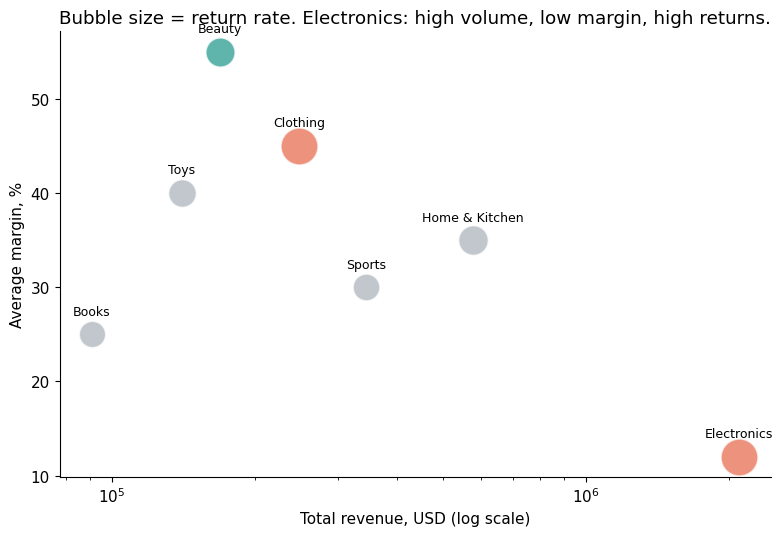

In [19]:
fig, ax = plt.subplots(figsize=(8, 5.5))
colors_map = {'Electronics': ORANGE, 'Clothing': ORANGE, 'Beauty': TEAL}
for _, row in q3_category.iterrows():
    c = colors_map.get(row['category'], GREY)
    ax.scatter(row['total_revenue'], row['avg_margin_pct'], s=row['return_rate_pct']*45,
               color=c, alpha=0.75, edgecolor='white', linewidth=1.2)
    ax.annotate(row['category'], (row['total_revenue'], row['avg_margin_pct']),
                textcoords='offset points', xytext=(0, 14), ha='center', fontsize=9)
ax.set_xscale('log')
ax.set_xlabel('Total revenue, USD (log scale)')
ax.set_ylabel('Average margin, %')
ax.set_title('Bubble size = return rate. Electronics: high volume, low margin, high returns.')
plt.tight_layout()
plt.show()

**Finding:** Electronics generates the most revenue but has the lowest margin (12%) and the highest return rate (17.9%) — a volume illusion. Beauty has the highest margin (55%) on comparatively small revenue with a moderate return rate — a hidden diamond worth scaling. Full discussion in the business analysis document, Case B.

## Case C — Discounts and high-value customers

In [20]:
cust_totals = orders.groupby('customer_id').agg(
    avg_discount=('discount_pct', 'mean'),
    order_count=('order_id', 'count'),
    total_spend=('net_amount', 'sum'),
).reset_index()
cust_totals['segment'] = np.where(cust_totals['avg_discount'] > 20, 'Heavy discount (>20%)', 'Rest')

segment_summary = cust_totals.groupby('segment').agg(
    customers=('customer_id', 'count'),
    avg_orders=('order_count', 'mean'),
    avg_spend=('total_spend', 'mean'),
    pct_one_time=('order_count', lambda x: round((x == 1).mean() * 100, 1))
).round(2)
segment_summary

,customers,avg_orders,avg_spend,pct_one_time
segment,,,,
Heavy discount (>20%),352,2.17,383.72,25.00
Rest,2648,4.35,"1,260.93",16.60


In [21]:
t_orders, p_orders = stats.ttest_ind(
    cust_totals.loc[cust_totals.segment == 'Heavy discount (>20%)', 'order_count'],
    cust_totals.loc[cust_totals.segment == 'Rest', 'order_count'],
    equal_var=False
)
print(f'Difference in order count, heavy-discount vs rest: t = {t_orders:.3f}, p = {p_orders:.6f}')

Difference in order count, heavy-discount vs rest: t = -24.823, p = 0.000000


Top 5% of customers (150 people) generate 35.1% of total net revenue


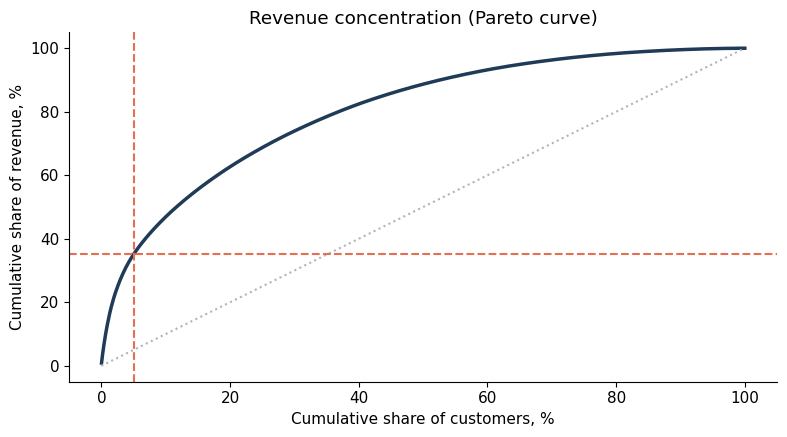

In [22]:
cust_sorted = cust_totals.sort_values('total_spend', ascending=False).reset_index(drop=True)
n5 = int(len(cust_sorted) * 0.05)
top5_share = 100 * cust_sorted.head(n5)['total_spend'].sum() / cust_sorted['total_spend'].sum()
print(f'Top 5% of customers ({n5} people) generate {top5_share:.1f}% of total net revenue')

cust_sorted['cum_customers_pct'] = (np.arange(1, len(cust_sorted) + 1)) / len(cust_sorted) * 100
cust_sorted['cum_revenue_pct'] = cust_sorted['total_spend'].cumsum() / cust_sorted['total_spend'].sum() * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(cust_sorted['cum_customers_pct'], cust_sorted['cum_revenue_pct'], color=NAVY, linewidth=2.5)
ax.plot([0, 100], [0, 100], color=GREY, linestyle=':', label='Perfect equality')
ax.axvline(5, color=ORANGE, linestyle='--')
ax.axhline(top5_share, color=ORANGE, linestyle='--')
ax.set_xlabel('Cumulative share of customers, %')
ax.set_ylabel('Cumulative share of revenue, %')
ax.set_title('Revenue concentration (Pareto curve)')
plt.tight_layout()
plt.show()

In [23]:
top5_ids = cust_sorted.head(n5)['customer_id']
top5_region = customers.loc[customers['customer_id'].isin(top5_ids), 'region'].value_counts()
top5_channel = customers.loc[customers['customer_id'].isin(top5_ids), 'acquisition_channel'].value_counts()
print(top5_region)
print()
print(top5_channel)

region
Europe            42
North America     42
Southeast Asia    38
Latin America     15
Middle East       13
Name: count, dtype: int64

acquisition_channel
Influencer     36
Organic        34
Referral       22
Social Ads     22
Paid Search    19
Email          17
Name: count, dtype: int64


**Finding:** Heavy-discount customers place 2.2 orders on average versus 4.4 for the rest, and 25% of them never return, versus 17% for the rest. The top 5% of customers (150 people) generate 35% of revenue and are concentrated in North America and Europe, disproportionately acquired via Influencer and Organic.

---
## Block 5 — A/B test: checkout redesign

Only orders with `ab_variant` in ('A', 'B') are in scope. Comparing average order value (`net_amount`) between the two groups, first overall, then split by customer type.

**New customer** = first order placed within 60 days of `signup_date`. **Repeat customer** = everyone else.

In [24]:
ab = orders.loc[orders['ab_variant'].isin(['A', 'B'])].merge(
    customers[['customer_id', 'signup_date']], on='customer_id', how='left'
)
ab['days_since_signup'] = (ab['order_date'] - ab['signup_date']).dt.days
ab['cust_type'] = np.where(ab['days_since_signup'] <= 60, 'New', 'Repeat')
print(f'Experiment window: {ab.order_date.min().date()} to {ab.order_date.max().date()}')
print(f"A: {(ab.ab_variant=='A').sum()} orders, B: {(ab.ab_variant=='B').sum()} orders")
ab.head()

Experiment window: 2024-06-01 to 2024-12-31
A: 3681 orders, B: 3674 orders


,order_id,customer_id,order_date,order_year,order_month,device,channel,discount_pct,gross_amount,discount_amount,net_amount,free_shipping,ab_variant,is_returned,signup_date,days_since_signup,cust_type
0,200002,10001,2024-08-08,2024,8,Desktop,Social Ads,5,260.38,13.02,239.94,1,B,0,2022-12-08,609,Repeat
1,200003,10001,2024-11-28,2024,11,Desktop,Influencer,10,"1,017.84",101.78,916.06,1,A,0,2022-12-08,721,Repeat
2,200004,10001,2024-11-05,2024,11,Mobile,Influencer,0,686.36,0.00,665.77,1,B,1,2022-12-08,698,Repeat
3,200005,10001,2024-08-14,2024,8,Mobile,Referral,0,764.44,0.00,741.51,1,B,0,2022-12-08,615,Repeat
4,200006,10001,2024-07-23,2024,7,Desktop,Paid Search,0,873.73,0.00,873.73,1,A,1,2022-12-08,593,Repeat


Overall comparison

In [25]:
overall = ab.groupby('ab_variant')['net_amount'].agg(['count', 'mean', 'std']).round(2)
print(overall)

a_all = ab.loc[ab.ab_variant == 'A', 'net_amount']
b_all = ab.loc[ab.ab_variant == 'B', 'net_amount']
t, p = stats.ttest_ind(a_all, b_all, equal_var=False)
print(f'\nWelch t-test: t = {t:.3f}, p = {p:.4f}')
print('At face value, B looks marginally higher, but the difference is not statistically significant.')

            count   mean    std
ab_variant                     
A            3681 281.73 359.74
B            3674 287.27 366.72

Welch t-test: t = -0.654, p = 0.5129
At face value, B looks marginally higher, but the difference is not statistically significant.


Split by new vs. repeat customers

In [26]:
subgroups = ab.groupby(['cust_type', 'ab_variant'])['net_amount'].agg(['count', 'mean', 'std']).round(2)
print(subgroups)

results = {}
for ct in ['New', 'Repeat']:
    a = ab.loc[(ab.cust_type == ct) & (ab.ab_variant == 'A'), 'net_amount']
    b = ab.loc[(ab.cust_type == ct) & (ab.ab_variant == 'B'), 'net_amount']
    t, p = stats.ttest_ind(a, b, equal_var=False)
    u, p_mw = stats.mannwhitneyu(a, b, alternative='two-sided')
    diff_pct = 100 * (b.mean() - a.mean()) / a.mean()
    results[ct] = dict(mean_a=a.mean(), mean_b=b.mean(), diff_pct=diff_pct, t=t, p=p, p_mannwhitney=p_mw)
    print(f'\n{ct}: mean A = {a.mean():.2f}, mean B = {b.mean():.2f}, diff = {diff_pct:+.1f}%, '
          f't-test p = {p:.4f}, Mann-Whitney p = {p_mw:.4f}')

                      count   mean    std
cust_type ab_variant                     
New       A             758 278.18 369.74
          B             744 341.47 452.29
Repeat    A            2923 282.65 357.16
          B            2930 273.51 340.32

New: mean A = 278.18, mean B = 341.47, diff = +22.8%, t-test p = 0.0031, Mann-Whitney p = 0.0004

Repeat: mean A = 282.65, mean B = 273.51, diff = -3.2%, t-test p = 0.3163, Mann-Whitney p = 0.7728


In [27]:
mix = ab.groupby('ab_variant')['cust_type'].value_counts(normalize=True).unstack().round(3) * 100
print('Share of new vs. repeat customers within each experiment arm (checking randomization balance):')
mix

Share of new vs. repeat customers within each experiment arm (checking randomization balance):


cust_type,New,Repeat
ab_variant,,
A,20.60,79.40
B,20.30,79.70


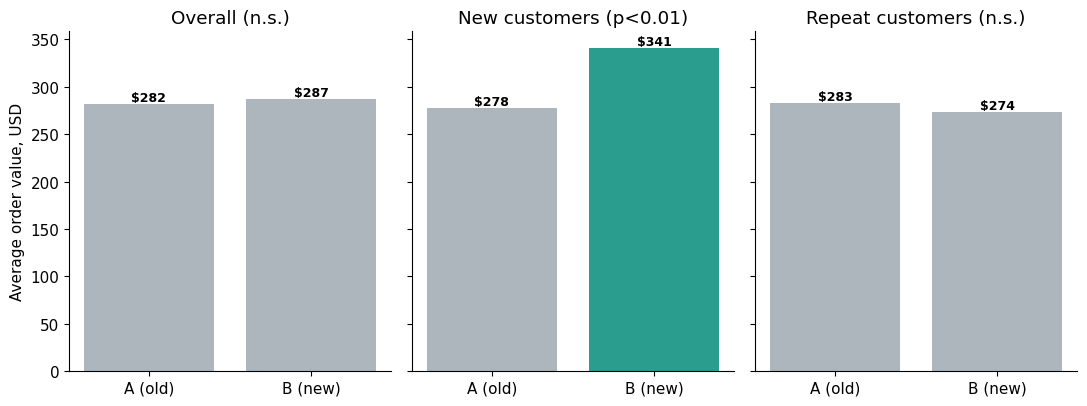

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4.2), sharey=True)
panels = [('Overall', overall['mean']), ('New customers', subgroups.loc['New']['mean']), ('Repeat customers', subgroups.loc['Repeat']['mean'])]
sig = [False, True, False]
for ax, (title, vals), s in zip(axes, panels, sig):
    colors = [GREY, TEAL if s else GREY]
    bars = ax.bar(['A (old)', 'B (new)'], [vals['A'], vals['B']], color=colors)
    for b, v in zip(bars, [vals['A'], vals['B']]):
        ax.text(b.get_x() + b.get_width()/2, v + 3, f'${v:.0f}', ha='center', fontweight='bold', fontsize=9)
    ax.set_title(title + (' (p<0.01)' if s else ' (n.s.)'))
axes[0].set_ylabel('Average order value, USD')
plt.tight_layout()
plt.show()

Interpretation

The aggregate result (Question 10) hides a real, statistically significant effect. New customers respond strongly to the redesigned checkout: average order value rises about 23% (p = 0.003, confirmed by Mann-Whitney p = 0.0004). Repeat customers show no meaningful change (p = 0.32). Because repeat customers make up roughly 80% of both arms — a proportion that is balanced across A and B, so this is not a randomization artifact — their flat result dilutes the strong new-customer effect down to statistical noise at the aggregate level.

This is the mechanism behind Simpson's-paradox-style reversals: the group-level average is a weighted blend, and a large, unaffected subgroup can mask a real effect in a smaller subgroup. A results summary that only reports the overall average would lead to the wrong decision — either shipping a change that mainly helps new customers while presenting it as a universal win, or shelving a change that is genuinely valuable for acquisition.

Full write-up, including how the result could be framed dishonestly in either direction and the honest recommendation, is in the business analysis document, Block 5.

---
## Summary of computed figures

This table consolidates every number used in the business analysis document, for traceability.

In [29]:
summary = pd.DataFrame([
    ['Total net revenue (all years)', f"${orders['net_amount'].sum():,.0f}"],
    ['Total orders', f"{len(orders):,}"],
    ['Average order value', f"${orders['net_amount'].mean():,.2f}"],
    ['Overall return rate', f"{100*orders['is_returned'].mean():.2f}%"],
    ['Best campaign ROI channel', f"{q5_channel_roi.iloc[0]['channel']} ({q5_channel_roi.iloc[0]['roi']:.2f}x)"],
    ['Worst campaign ROI channel', f"{q5_channel_roi.iloc[-1]['channel']} ({q5_channel_roi.iloc[-1]['roi']:.2f}x)"],
    ['Highest LTV acquisition channel', f"{ltv_by_channel.iloc[0]['acquisition_channel']} (${ltv_by_channel.iloc[0]['avg_ltv']:,.0f})"],
    ['Top 5% customer revenue share', f'{top5_share:.1f}%'],
    ['Heavy-discount customer avg orders', f"{segment_summary.loc['Heavy discount (>20%)', 'avg_orders']:.2f}"],
    ['Rest customer avg orders', f"{segment_summary.loc['Rest', 'avg_orders']:.2f}"],
    ['A/B overall p-value', f'{p:.4f}'],
    ['A/B new-customer effect', f"{results['New']['diff_pct']:+.1f}% (p={results['New']['p']:.4f})"],
    ['A/B repeat-customer effect', f"{results['Repeat']['diff_pct']:+.1f}% (p={results['Repeat']['p']:.4f})"],
], columns=['Metric', 'Value'])
summary

,Metric,Value
0,Total net revenue (all years),"$3,474,016"
1,Total orders,"12,274"
2,Average order value,$283.04
3,Overall return rate,9.77%
4,Best campaign ROI channel,Organic (8.02x)
5,Worst campaign ROI channel,Paid Search (1.33x)
6,Highest LTV acquisition channel,"Influencer ($1,986)"
7,Top 5% customer revenue share,35.1%
8,Heavy-discount customer avg orders,2.17
9,Rest customer avg orders,4.35
